# 02 — Baseline & Reward Rates

**Goal:** Compute the random-policy baseline (the number to beat) and raw per-template reward rates.

This notebook answers:
- What is the overall reward rate under random template selection?
- Which templates have the highest/lowest raw reward rates?
- Why can raw rates be misleading? (motivation for RDS)

## Setup

In [10]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

from src.data_loader import iter_parquet_chunks, load_sample
from src.scoring.difference_score import compute_template_reward_rates

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

CHUNK_SIZE = 1_000_000
INTERMEDIATE_DIR = os.path.join("..", "data", "intermediate")

print("Ready!")

Ready!


---
## 1. Compute Baseline & Reward Rates on FULL Training Data (Chunked)

We stream through all ~88M training rows in 1M-row chunks. Each chunk uses ~200 MB, then gets freed. We only keep per-template sums and counts in memory (a few KB).

In [2]:
import time

# Accumulators
reward_sum = defaultdict(float)   # template → sum of rewards
reward_count = defaultdict(int)   # template → count
total_reward = 0.0
total_rows = 0

t0 = time.time()
for chunk in iter_parquet_chunks("train", CHUNK_SIZE):
    # Per-template stats
    grouped = chunk.groupby("selected_template")["session_end_completed"]
    for tmpl, grp in grouped:
        reward_sum[tmpl] += grp.sum()
        reward_count[tmpl] += len(grp)
    
    # Global baseline stats
    total_reward += chunk["session_end_completed"].sum()
    total_rows += len(chunk)
    del chunk

elapsed = time.time() - t0

# Compute final values
baseline = total_reward / total_rows
reward_rates = {t: reward_sum[t] / reward_count[t] for t in reward_sum}
counts = dict(reward_count)

print(f"\n✅ Processed {total_rows:,} rows in {elapsed:.0f}s")
print(f"\nRandom Baseline: {baseline:.6f} ({baseline:.2%})")
print(f"\nReward rates for {len(reward_rates)} templates:")
for t in sorted(reward_rates):
    print(f"  Template {t}: reward_rate = {reward_rates[t]:.4f}, count = {counts[t]:,}")

[data_loader] Found 3 parquet files for 'train' split
[iter_chunks] File 1/3: part-00000-9b4bba6b-feac-44b1-a155-17c796835cca-c000.snappy.parquet (25,613,243 rows, 13 row groups)
[postprocess] Processing 1,000,000 rows in 1 batch(es) of 1,000,000...
  Batch 1/1: rows 0-1,000,000 done in 7.8s | Total: 1,000,000/1,000,000 (100%) | ETA: 0s
[postprocess] All 1,000,000 rows processed in 7.8s
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 1,000,000)
[postprocess] Processing 1,000,000 rows in 1 batch(es) of 1,000,000...
  Batch 1/1: rows 0-1,000,000 done in 23.2s | Total: 1,000,000/1,000,000 (100%) | ETA: 0s
[postprocess] All 1,000,000 rows processed in 23.2s
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 2,000,000)
[postprocess] Processing 1,000,000 rows in 1 batch(es) of 1,000,000...
  Batch 1/1: rows 0-1,000,000 done in 12.0s | Total: 1,000,000/1,000,000 (100%) | ETA: 0s
[postprocess] All 1,000,000 rows processed in 12.0s
[iter_chunks] Yielding chunk: 1,000,000 

---
## 2. Random Baseline — The Number to Beat

The dataset was collected under a **random policy** — Duolingo picked each template uniformly at random from the eligible set. So the average reward in the data equals the random policy's performance.

Everything we build later must beat this number. If it doesn't, our algorithm is worse than flipping a coin.

In [3]:
print(f"{'='*40}")
print(f"  RANDOM BASELINE: {baseline:.6f} ({baseline:.2%})")
print(f"{'='*40}")
print(f"\n  Computed from {total_rows:,} rows (FULL training set)")
print(f"\n  This means: under random template selection,")
print(f"  about {baseline:.1%} of users complete a lesson within 2 hours.")
print(f"\n  Our goal: beat {baseline:.4f} using smarter template choices.")

  RANDOM BASELINE: 0.143826 (14.38%)

  Computed from 87,665,839 rows (FULL training set)

  This means: under random template selection,
  about 14.4% of users complete a lesson within 2 hours.

  Our goal: beat 0.1438 using smarter template choices.


---
## 3. Per-Template Reward Rates

For each template A–L, we compute:

$$\text{reward\_rate}(a) = \frac{\text{# times template a was sent AND user engaged}}{\text{# times template a was sent}}$$

This is the simplest way to rank templates — but as we'll see, it has a serious flaw.

In [4]:
# reward_rates and counts already computed from full data above
print(f"Reward rates computed from FULL training data ({total_rows:,} rows):")
for t in sorted(reward_rates):
    print(f"  Template {t}: reward_rate = {reward_rates[t]:.4f}, count = {counts[t]:,}")

Reward rates computed from FULL training data (87,665,839 rows):
  Template A: reward_rate = 0.2690, count = 3,472,696
  Template B: reward_rate = 0.1285, count = 9,059,625
  Template C: reward_rate = 0.4123, count = 2,523,858
  Template D: reward_rate = 0.1310, count = 9,054,749
  Template E: reward_rate = 0.1295, count = 9,060,589
  Template F: reward_rate = 0.1289, count = 9,057,400
  Template G: reward_rate = 0.1316, count = 9,058,068
  Template H: reward_rate = 0.1287, count = 9,124,283
  Template J: reward_rate = 0.1304, count = 9,062,686
  Template K: reward_rate = 0.1316, count = 9,129,646
  Template L: reward_rate = 0.1317, count = 9,062,239


In [5]:
# Build a summary dataframe
summary = pd.DataFrame({
    "template": list(reward_rates.keys()),
    "reward_rate": list(reward_rates.values()),
    "count": [counts[t] for t in reward_rates.keys()]
}).sort_values("reward_rate", ascending=False).reset_index(drop=True)

summary["rank"] = range(1, len(summary) + 1)
print("Template ranking by raw reward rate:\n")
print(summary[["rank", "template", "reward_rate", "count"]].to_string(index=False))

Template ranking by raw reward rate:

 rank template  reward_rate   count
    1        C     0.412298 2523858
    2        A     0.268958 3472696
    3        L     0.131680 9062239
    4        G     0.131586 9058068
    5        K     0.131572 9129646
    6        D     0.130969 9054749
    7        J     0.130362 9062686
    8        E     0.129533 9060589
    9        F     0.128914 9057400
   10        H     0.128724 9124283
   11        B     0.128534 9059625


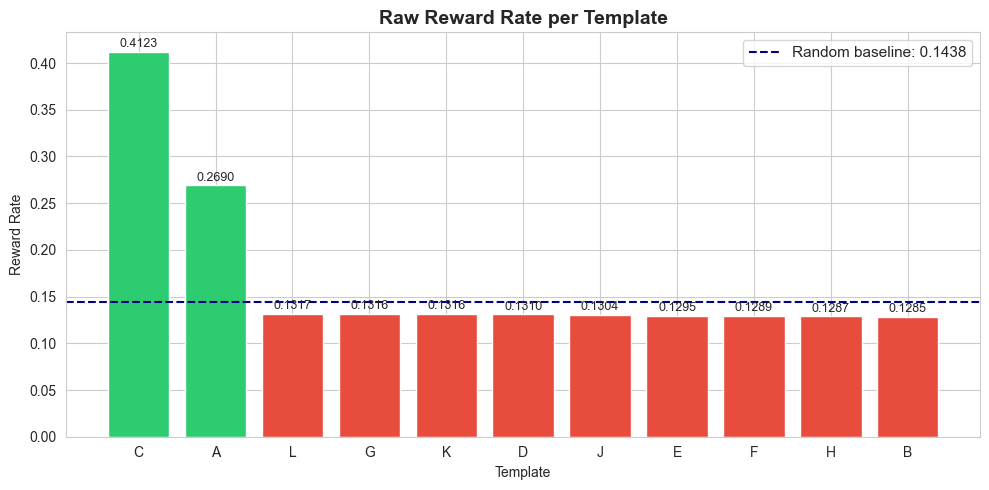

In [6]:
# Bar chart of reward rates
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#2ecc71" if r > baseline else "#e74c3c" for r in summary["reward_rate"]]

bars = ax.bar(summary["template"], summary["reward_rate"], color=colors, edgecolor="white")
ax.axhline(y=baseline, color="navy", linestyle="--", linewidth=1.5,
           label=f"Random baseline: {baseline:.4f}")

ax.set_title("Raw Reward Rate per Template", fontsize=14, fontweight="bold")
ax.set_xlabel("Template")
ax.set_ylabel("Reward Rate")
ax.legend(fontsize=11)

# Annotate bars
for bar, rate in zip(bars, summary["reward_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{rate:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

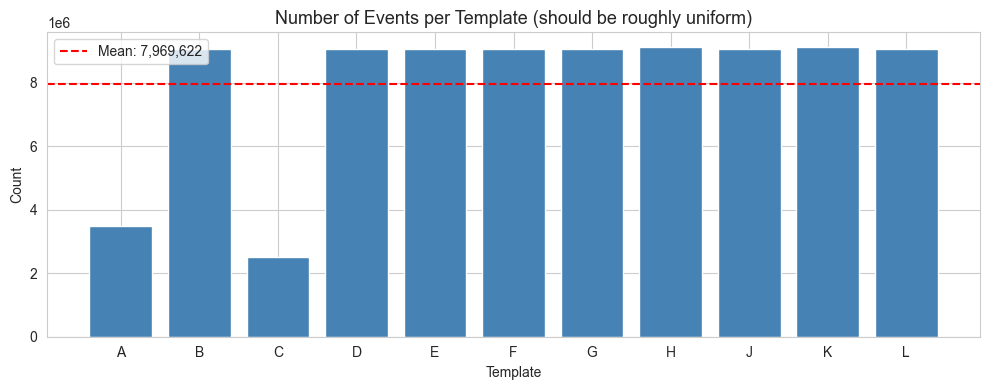

Count range: 2,523,858 – 9,129,646
Note: counts are NOT perfectly equal because eligibility varies per event.


In [7]:
# How many events per template? (should be ~uniform since random policy)
fig, ax = plt.subplots(figsize=(10, 4))

count_df = summary.sort_values("template")
ax.bar(count_df["template"], count_df["count"], color="steelblue", edgecolor="white")
ax.axhline(y=count_df["count"].mean(), color="red", linestyle="--",
           label=f"Mean: {count_df['count'].mean():,.0f}")

ax.set_title("Number of Events per Template (should be roughly uniform)", fontsize=13)
ax.set_xlabel("Template")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Count range: {count_df['count'].min():,} – {count_df['count'].max():,}")
print(f"Note: counts are NOT perfectly equal because eligibility varies per event.")

---
## 4. Why Raw Reward Rates Can Be Misleading

The raw reward rate treats every event equally. But there's an important confounding factor:

**Different templates are eligible for different users at different times.**

Imagine template A is mostly eligible for **active users** (who engage with anything), while template B is mostly eligible for **dormant users** (who rarely engage). Template A's raw reward rate will look higher — but that's because of the *users*, not the *template*.

Let's check whether the eligible set composition actually varies across templates.

In [8]:
# For eligibility analysis, we stream through full data again
# For each template, count: how many events it's eligible in + total reward when eligible vs not

from src.data_loader import parse_eligible_templates

templates = sorted(reward_rates.keys())

elig_reward_sum = {t: 0.0 for t in templates}   # reward sum when t IS eligible
elig_count = {t: 0 for t in templates}           # count when t IS eligible
not_elig_reward_sum = {t: 0.0 for t in templates}
not_elig_count = {t: 0 for t in templates}

for chunk in iter_parquet_chunks("train", CHUNK_SIZE):
    for _, row in chunk.iterrows():
        elig = row["eligible_templates"]
        if isinstance(elig, str):
            elig = parse_eligible_templates(elig)
        elig_set = set(elig) if isinstance(elig, list) else set()
        reward = row["session_end_completed"]
        
        for t in templates:
            if t in elig_set:
                elig_reward_sum[t] += reward
                elig_count[t] += 1
            else:
                not_elig_reward_sum[t] += reward
                not_elig_count[t] += 1
    del chunk

eligible_stats = []
for t in templates:
    pct = elig_count[t] / total_rows if total_rows > 0 else 0
    r_elig = elig_reward_sum[t] / elig_count[t] if elig_count[t] > 0 else 0
    r_not = not_elig_reward_sum[t] / not_elig_count[t] if not_elig_count[t] > 0 else 0
    eligible_stats.append({
        "template": t,
        "pct_eligible": pct,
        "reward_when_eligible": r_elig,
        "reward_when_not_eligible": r_not,
        "gap": r_elig - r_not,
    })

elig_df = pd.DataFrame(eligible_stats)
print("Reward rate when template IS vs IS NOT in the eligible set (FULL DATA):\n")
print(elig_df.to_string(index=False))

print(f"\nIf all gaps were zero, eligibility wouldn't matter.")
print(f"Non-zero gaps = eligibility is confounded with user engagement.")
print(f"→ This is exactly why we need Relative Difference Scores (next notebook).")

[data_loader] Found 3 parquet files for 'train' split
[iter_chunks] File 1/3: part-00000-9b4bba6b-feac-44b1-a155-17c796835cca-c000.snappy.parquet (25,613,243 rows, 13 row groups)
[postprocess] Processing 1,000,000 rows in 1 batch(es) of 1,000,000...
  Batch 1/1: rows 0-1,000,000 done in 4.1s | Total: 1,000,000/1,000,000 (100%) | ETA: 0s
[postprocess] All 1,000,000 rows processed in 4.1s
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 1,000,000)
[postprocess] Processing 1,000,000 rows in 1 batch(es) of 1,000,000...
  Batch 1/1: rows 0-1,000,000 done in 4.9s | Total: 1,000,000/1,000,000 (100%) | ETA: 0s
[postprocess] All 1,000,000 rows processed in 4.9s
[iter_chunks] Yielding chunk: 1,000,000 rows (total yielded: 2,000,000)
[postprocess] Processing 1,000,000 rows in 1 batch(es) of 1,000,000...
  Batch 1/1: rows 0-1,000,000 done in 3.2s | Total: 1,000,000/1,000,000 (100%) | ETA: 0s
[postprocess] All 1,000,000 rows processed in 3.2s
[iter_chunks] Yielding chunk: 1,000,000 rows

---
## 5. Summary

| What we computed | Value |
|-----------------|-------|
| **Random baseline** | Overall mean reward rate — the number to beat |
| **Per-template reward rates** | Raw success rate for each template A–L |
| **Template ranking** | Which templates look best *naively* |
| **Confounding evidence** | Eligibility composition varies → raw rates are biased |

**Key takeaway:** Raw reward rates are a useful first look, but they mix up template quality with user quality. A template might look great just because it's eligible for active users.

**Next notebook:** `03_rds_scoring.ipynb` — compute **Relative Difference Scores** that separate template quality from user quality.

In [9]:
# Save intermediate results for next notebooks
results_02 = {
    "baseline": baseline,
    "reward_rates": reward_rates,
    "counts": counts,
    "total_rows": total_rows,
}

save_path = os.path.join(INTERMEDIATE_DIR, "02_results.json")
with open(save_path, "w") as f:
    json.dump(results_02, f, indent=2)

print(f"✅ Saved to {save_path}")
print(f"   Next notebooks will load these full-data results.")

✅ Saved to ../data/intermediate/02_results.json
   Next notebooks will load these full-data results.
